# Player Win Probality in a Dice-Based Game System using Monte Carlo Simulation

___
## Abstract
***Work in Progress***
___

## Introduction
### Background
&emsp; Probability is a fundamental element in game design, it often dictates how an in-game scenario plays out. Moreover, many video games rely on probability in their combat  system, namely tabletop RPGs like Dungeons and Dragons. This analysis will be focused on analyzing the probability of in-game combat scenarios

&emsp; This study analyzes a simulation of a dice-based game. In this game simulation, a player is given a 20-sided die.The player is also given 50 HP and can deal damage worth 2 rolls of a 6-sided die. In this scenario, the player is fighting an enemy which has 100 HP and can deal a fixed 5 points of damage. The player will be damaged if the result of the 20-sided die is below or equal to 11, else the player will damage the enemy and will not take the damage from the enemy. Subsequently, if the player rolls a 20, the damage that the player will deal will be doubled, but if the player rolls a 1, the enemy will deal double the damage.

&emsp; The study will run a Monte Carlo simulation using Python, simulating 10,000 cases of the combat scenario to estimate the win probability of the player and the impact of in-game variables that influence the win probability.

### Statement of the Problem
This analysis aims to answer two questions:

1. What is the probability of the player winning?
2. What affects the player win rate the most?
    - The damage dealt and taken
    - The hit chance of the player
    - The HP of player and enemy

### Hypothesis
&emsp; The following hypotheses are based on the variables present in the simulation. In addition these hypotheses will be tested with a significance level of 0.05

1. Problem 1 - Player's win probability

&emsp; It is hypothesized that the player will have less than 40% win rate due to the player relying on probability to deal damage, more chances to take damage, and lower HP.

- H₀: The player's win rate is greater than or equal to 40% (p >= 0.4)
- H₁: The player's win rate is less than 40% (p < 0.4)

2. Problem 2 - Primary Factor

&emsp; It is hypothesized that the mean of damage dealt of the player is the biggest factor on win probability, as higher average of damage reduces the rounds it takes to defeat the enemy

- H₀: The mean damage dealt by the player is not the primary factor on win probability
- H₁: The mean damage dealt by the player is the primary factor influencing win probability

___
## Analysis
### Data Collection and Gathering

&emsp; The data that will be used in the following analysis will be generated by a program that runs a simulation of the combat scenario and repeats it 10,000 times. Each individual run will record the necessary data such as whether the player won or lost, how many rounds it took to conclude the simulation, how many hits and misses the player took, how much damage the player and enemy dealt, how much HP the player and enemy have remaining, and the number of critical hits and misses. This record will be appended into a row of a dictionary with the respective columns. 

&emsp; This simulation will be contained in a function with parameters like player HP, enemy HP, player damage die, and enemy damage. This function will also use constants namely, sample size that is equal to 10,000 and a multiplier with a value of 2 to multiply the damage when a critical hit or miss occurs.

&emsp; Furthermore, this simulation will be using Python packages, specifically NumPy for calculation as well as pseudo-random number generation, and Pandas for data storage and manipulation. The entire simulation is contained within main.py and functions.py, with the notebook.ipynb serving as the environment for analysis. 

### A.  Data Collected
- Table 1: The output of the simulation which contains the default columns such result, rounds, damage dealt, remaining HP, and critical and default hit and miss counts as well as 10,000 runs.


In [1]:
from main import *
    
print(simulation_results)

0.5182
      result  rounds  damage_player_dealt  damage_enemy_dealt  \
run                                                             
1       loss      17                   69                  50   
2       loss      14                   26                  50   
3       loss      19                   70                  50   
4       loss      18                   56                  50   
5       loss      18                   77                  50   
...      ...     ...                  ...                 ...   
9996    loss      21                   81                  50   
9997    loss      15                   24                  50   
9998    loss      18                   72                  50   
9999    loss      19                   77                  50   
10000   loss      17                   47                  50   

       remaining_player_hp  remaining_enemy_hp  miss_count  hit_count  nat20  \
run                                                                


### 1. Player Win Probability
#### A. Methods
&emsp; This problem requires the proportion of the player wins in the 10,000 simulation runs to calculate the estimation of the win probability of the player. This estimated win probability will be subjected to proportion testing, to determine whether the null hypothesis has failed to be rejected or rejected with a significance level of 5%. Moreover, the tools that will be utilized in this analysis will be Python packages, namely NumPy, Pandas,Scipy.Stats, Matplotlib, and Seaborn.

#### B. Analysis
&emsp; The first task is visualizing the results in the simulation to get a general sense of the win probability. This is done by data visualization Python packages such as Matplotlib.pyplot and Seaborn.


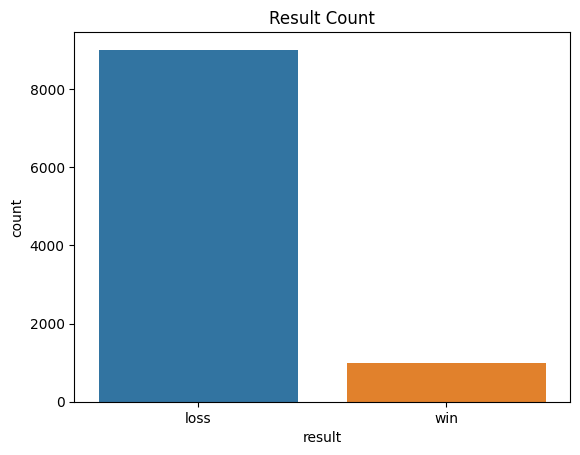

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creating a count plot for results
win_count_plot = sns.countplot(data=simulation_results, x="result", hue = "result",)
win_count_plot.set_title("Result Count")
sns.set_context("paper")
plt.show()

&emsp; This count plot shows the significant gap between the amount of instances that the player won against the amount of instances it lost. This implies that the hypothesized win probability of less than 40% might be plausible and even generous.

&emsp; To determine the exact value of the win probability, it is required to calculate its proportion. This is done by data manipulation using Pandas and NumPy.

In [3]:
import pandas as pd
import numpy as np

win_probability = (simulation_results["result"] == "win").mean()

print(win_probability)

0.0991


&emsp; The estimated value of the win probability based on the simulation is 0.0991 or 9.91%, which is significantly lower than the null hypothesis. In fact, there’s a 30.9% point difference between the estimated win probability and the null hypothesis. 

&emsp; Before proceeding into hypothesis testing, it is imperative to calculate the confidence interval to determine the range of which the true win probability lies. This process will be done by the NumPy package.


In [4]:
from functions import SAMPLE_SIZE

std_error = np.sqrt(win_probability * (1 - win_probability) / SAMPLE_SIZE)

win_probability_low = win_probability - 1.96 * std_error
win_probability_high = win_probability + 1.96 * std_error

print(win_probability_low, win_probability_high)

0.09324359379564566 0.10495640620435433


&emsp; The results state that the simulation is 95% confident that the true win probability lies between 9.32% and 	10.50%. Which, again, highlights the gap between the approximated win probability and the null hypothesis.

&emsp; Nevertheless, while these values strongly suggest that the null hypothesis should be rejected, a formal hypothesis test should be conducted to confirm this. Therefore it’s a must to conduct a proportion test with a significance level of 0.05 to determine whether these values differ significantly. This will be done using SciPy.stats and NumPy packages.

In [5]:
import scipy.stats as ss

alpha= 0.05
hypothesized_probability = 0.4
numerator = win_probability - hypothesized_probability
denominator = np.sqrt(hypothesized_probability * (1 - hypothesized_probability) / SAMPLE_SIZE)

z_score = numerator / denominator
p_value = ss.norm.cdf(z_score)

print(alpha, p_value, p_value <= alpha)

0.05 0.0 True


&emsp; The test results in a p value of 0 due to the large negative difference between the win probability and the hypothesized probability, which means the null hypothesis of the win probability is greater than or equal to 40% will be rejected.

#### C. Conclusions
&emsp; From the visualization to the proportion tests the hypothesized probability threshold of 40% is not even close. This highly suggests that the odds of the player winning a single combat encounter are always in the enemy's favor, with the player's win probability ranging between 9.32% and 10.50% with 95% confidence. This is caused by a number of variables that are not in the player's advantage, namely the player's damage solely relies on probability, the higher chance of missing than hitting the enemy (45% of hitting the enemy), and the HP advantage of the enemy which is double that of the player. The underestimation of the disadvantages of the player resulted in a null hypothesis that is significantly lower than the actual win probability.

### Problem 2 - Primary Factor